# 02 · Baselines: TF-IDF + logistic regression, and a fastText-style bag of embeddings
Owner: **Nshuti Shalom Silver Jr**

Both baselines ignore word order (apart from short n-grams), so they answer: *how far do we get
without modelling the sequence?*

| Baseline | Order | Why include it |
|---|---|---|
| **TF-IDF (word + char n-grams) + logistic regression** | only within 1–2-word / 2–5-char windows | The classic, very strong text-classification baseline; character n-grams handle Swahili morphology. |
| **fastText-style bag of embeddings** (Joulin et al., 2017) | none (averaged word + hashed bigram vectors) | A *neural* model without sequence modelling: separates "being neural" from "modelling order". |

Selection uses **validation log loss** (official metric). The test split is used once at the end.

## 0 · Setup

In [6]:
import os, sys, shutil, subprocess
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    REPO_URL = "https://github.com/N-SilverJr/swahili-news-sequential.git"
    REPO_DIR = Path("/content/swahili-news-sequential")
    DRIVE_DATA = Path("/content/drive/MyDrive/swahili-news")
    LOCAL_DATA = Path("/content/data")
    if not REPO_DIR.exists():
        subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
    if not (LOCAL_DATA / ".ready").exists():
        LOCAL_DATA.mkdir(parents=True, exist_ok=True)
        for f in DRIVE_DATA.glob("*.csv"):
            shutil.copy(f, LOCAL_DATA)
        (LOCAL_DATA / ".ready").touch()
    os.environ["DATA_DIR"] = str(LOCAL_DATA)
    os.environ["CACHE_DIR"] = str(DRIVE_DATA / "cache")
    os.environ["OUTPUT_BACKUP_DIR"] = str(DRIVE_DATA / "outputs")
else:
    if Path.cwd().name == "notebooks":
        os.chdir(Path.cwd().parent)
sys.path.insert(0, os.getcwd())
print("Working directory:", os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/swahili-news-sequential


In [7]:
import numpy as np
import pandas as pd
from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from src import config as C
from src.data import get_splits, split_frames, encode_labels, load_unlabelled
from src.datasets import TokenDataset, pad_collate
from src.evaluate import compute_metrics, log_experiment, save_final_results, make_submission, show_log
from src.models import FastTextBag
from src.pipeline import run_experiments, finalize
from src.text import tokenize, head_tail, Vocab, encode_corpus, SW_STOPWORDS
from src.utils import set_seed, Timer

MEMBER = "Nshuti Shalom Silver Jr"
set_seed(C.SEED)
df = get_splits()
tr, va, te = split_frames(df)
ytr, yva, yte = (encode_labels(d.label) for d in (tr, va, te))
zindi = load_unlabelled()
K = len(C.CLASSES)

Split sizes: {'train': 3605, 'test': 773, 'val': 773}


## Part A · TF-IDF + logistic regression
Every variant is a function of the article text, so the same code builds each experiment.

In [8]:
def tfidf_features(cfg, fit_texts, *other):
    prep = lambda t: " ".join(head_tail(tokenize(t), cfg.get("max_words", 10**6), cfg.get("head_frac", 1.0)))
    if cfg.get("tail_only"):
        prep = lambda t: " ".join(tokenize(t)[-cfg["max_words"]:])
    stop = SW_STOPWORDS if cfg.get("stopwords") else None
    vecs = [TfidfVectorizer(preprocessor=prep, tokenizer=str.split, token_pattern=None, lowercase=False,
                            ngram_range=(1, cfg.get("word_ngrams", 2)), min_df=2, max_features=200_000,
                            sublinear_tf=True, stop_words=list(stop) if stop else None)]
    if cfg.get("char"):
        vecs.append(TfidfVectorizer(preprocessor=prep, analyzer="char_wb", ngram_range=(2, 5), min_df=3,
                                    max_features=300_000, sublinear_tf=True))
    Xs = [hstack([v.fit_transform(fit_texts) for v in vecs]).tocsr()]
    for texts in other:
        Xs.append(hstack([v.transform(texts) for v in vecs]).tocsr())
    return Xs


def run_lr(exp):
    cfg = exp["cfg"]
    Xtr, Xva = tfidf_features(cfg, tr.content, va.content)
    best = None
    for Cval in ([4.0] if C.QUICK else [1.0, 4.0, 16.0]):        # C tuned on validation log loss
        clf = LogisticRegression(C=Cval, max_iter=3000, class_weight="balanced" if cfg.get("balanced") else None)
        clf.fit(Xtr, ytr)
        m = compute_metrics(yva, clf.predict_proba(Xva), K)
        if best is None or m["log_loss"] < best[1]["log_loss"]:
            best = (Cval, m, clf)
    return best


LR_EXPS = [
    dict(id="BL-01", description="TF-IDF word 1-2 grams + LR", cfg={},
         hypothesis="Topic words alone separate most categories.", motivated_by="Starting point"),
    dict(id="BL-02", description="+ character 2-5 grams", cfg={"char": True},
         hypothesis="Char n-grams share evidence across inflected forms (mchezo, wachezaji, kucheza).",
         motivated_by="EDA 5: 53% of word types are hapax; many forms of one stem"),
    dict(id="BL-03", description="+ char n-grams + balanced class weights", cfg={"char": True, "balanced": True},
         hypothesis="Re-weighting improves recall on kimataifa/burudani (54 and 17 articles).",
         motivated_by="EDA 2: 118:1 imbalance; BL-02 per-class recall on minority classes"),
    dict(id="BL-04", description="word+char, FIRST 128 words only", cfg={"char": True, "max_words": 128},
         hypothesis="News puts the key facts first (inverted pyramid), so the head carries most signal.",
         motivated_by="EDA 8: keyword position; informs truncation choice for sequence models"),
    dict(id="BL-05", description="word+char, LAST 128 words only", cfg={"char": True, "max_words": 128, "tail_only": True},
         hypothesis="The end of an article is less informative than the head.",
         motivated_by="BL-04: compare head vs tail at the same length"),
    dict(id="BL-06", description="word+char, Swahili stop-words removed", cfg={"char": True, "stopwords": True},
         hypothesis="Function words are noise for topic classification.",
         motivated_by="Common preprocessing choice; checking whether it actually helps here"),
]
results_lr = {}
for e in LR_EXPS:
    with Timer() as t:
        Cval, m, clf = run_lr(e)
    results_lr[e["id"]] = (e, Cval, m)
    log_experiment(e["id"], MEMBER, "TF-IDF LR", e["description"], e["hypothesis"], {**e["cfg"], "C": Cval},
                   m, e["motivated_by"], t.seconds)
    print(f"{e['id']}: val log loss {m['log_loss']:.4f} | acc {m['accuracy']:.3f} | macro-F1 {m['macro_f1']:.3f} | C={Cval}")

/content/swahili-news-sequential/src/evaluate.py:172: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  log = pd.concat([log, pd.DataFrame([row])], ignore_index=True).sort_values("exp_id")


BL-01: val log loss 0.3507 | acc 0.869 | macro-F1 0.523 | C=16.0
BL-02: val log loss 0.3413 | acc 0.877 | macro-F1 0.572 | C=4.0
BL-03: val log loss 0.3291 | acc 0.882 | macro-F1 0.611 | C=16.0
BL-04: val log loss 0.3693 | acc 0.867 | macro-F1 0.522 | C=4.0
BL-05: val log loss 0.4109 | acc 0.846 | macro-F1 0.509 | C=4.0
BL-06: val log loss 0.3432 | acc 0.878 | macro-F1 0.572 | C=4.0


## Part B · fastText-style bag of embeddings (neural, order-free)

In [9]:
import importlib
import torch
importlib.import_module("torch._utils")
print("torch._utils loaded OK")

torch._utils loaded OK


In [10]:
vocab = Vocab(tr.content.map(tokenize))
seq = {name: encode_corpus(d.content, vocab, max_len=10**6) for name, d in
       {"tr": tr, "va": va, "te": te, "z": zindi}.items()}
print("vocabulary size:", len(vocab))


def make_datasets(p):
    return TokenDataset(seq["tr"], ytr), TokenDataset(seq["va"], yva)


def build_model(p):
    return FastTextBag(len(vocab), K, dim=p.get("dim", 100), bigrams=p.get("bigrams", True))


FT_EXPS = [
    dict(id="FT-01", description="Averaged word embeddings (unigrams)", params={"bigrams": False},
         hypothesis="A learned dense bag of words matches TF-IDF.", motivated_by="Neural order-free reference"),
    dict(id="FT-02", description="+ hashed bigram embeddings", params={"bigrams": True},
         hypothesis="Bigrams add a little local order ('waziri wa', 'ligi kuu').", motivated_by="FT-01"),
]
best_ft, ft_summary = run_experiments(
    FT_EXPS, build_model, make_datasets, member=MEMBER, model_name="fastText bag", n_classes=K, y_train=ytr,
    default_train=dict(epochs=30, lr=5e-3, batch_size=64, weight_decay=0.0, patience=5, num_workers=0),
    collate_fn=pad_collate)
ft_summary.round(4)

vocabulary size: 26854

===== FT-01: Averaged word embeddings (unigrams) =====
ep   1 | train loss 1.5580 acc 0.299 | val loss 1.4087 acc 0.502 F1 0.239 | 1s
ep   2 | train loss 1.1663 acc 0.585 | val loss 0.9048 acc 0.731 F1 0.408 | 0s
ep   3 | train loss 0.6980 acc 0.762 | val loss 0.5473 acc 0.825 F1 0.495 | 0s
ep   4 | train loss 0.4590 acc 0.853 | val loss 0.4307 acc 0.838 F1 0.502 | 0s
ep   5 | train loss 0.3466 acc 0.888 | val loss 0.3844 acc 0.854 F1 0.513 | 0s
ep   6 | train loss 0.2722 acc 0.917 | val loss 0.3566 acc 0.859 F1 0.517 | 0s
ep   7 | train loss 0.2192 acc 0.930 | val loss 0.3497 acc 0.859 F1 0.516 | 0s
ep   8 | train loss 0.1695 acc 0.948 | val loss 0.3445 acc 0.863 F1 0.519 | 0s
ep   9 | train loss 0.1318 acc 0.962 | val loss 0.3448 acc 0.865 F1 0.565 | 0s
ep  10 | train loss 0.1039 acc 0.975 | val loss 0.3443 acc 0.867 F1 0.565 | 0s
ep  11 | train loss 0.0836 acc 0.984 | val loss 0.3492 acc 0.867 F1 0.565 | 0s
ep  12 | train loss 0.0670 acc 0.989 | val loss 0.35

/content/swahili-news-sequential/src/evaluate.py:172: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  log = pd.concat([log, pd.DataFrame([row])], ignore_index=True).sort_values("exp_id")



===== FT-02: + hashed bigram embeddings =====
ep   1 | train loss 1.5796 acc 0.265 | val loss 1.4766 acc 0.564 F1 0.344 | 1s
ep   2 | train loss 1.2360 acc 0.588 | val loss 0.9645 acc 0.677 F1 0.328 | 1s
ep   3 | train loss 0.7228 acc 0.754 | val loss 0.5753 acc 0.801 F1 0.473 | 1s
ep   4 | train loss 0.4289 acc 0.879 | val loss 0.4477 acc 0.858 F1 0.514 | 1s
ep   5 | train loss 0.2818 acc 0.926 | val loss 0.3986 acc 0.854 F1 0.513 | 1s
ep   6 | train loss 0.1893 acc 0.950 | val loss 0.3748 acc 0.865 F1 0.521 | 1s
ep   7 | train loss 0.1315 acc 0.965 | val loss 0.3719 acc 0.853 F1 0.512 | 1s
ep   8 | train loss 0.0906 acc 0.985 | val loss 0.3682 acc 0.856 F1 0.514 | 1s
ep   9 | train loss 0.0633 acc 0.992 | val loss 0.3669 acc 0.859 F1 0.516 | 1s
ep  10 | train loss 0.0464 acc 0.995 | val loss 0.3686 acc 0.859 F1 0.516 | 1s
ep  11 | train loss 0.0348 acc 0.997 | val loss 0.3703 acc 0.858 F1 0.516 | 1s
ep  12 | train loss 0.0267 acc 0.998 | val loss 0.3782 acc 0.858 F1 0.515 | 1s
ep  1

,exp_id,description,val_log_loss,val_accuracy,val_macro_f1,val_weighted_f1,val_top2_accuracy,val_ece,val_roc_auc_ovr_macro,best_epoch,epochs_run,train_gap_acc,params,minutes
0,FT-01,Averaged word embeddings (unigrams),0.3443,0.8668,0.5654,0.8616,0.9897,0.0360,0.9716,10,15,0.1314,2685905,0.3177
1,FT-02,+ hashed bigram embeddings,0.3669,0.8590,0.5161,0.8523,0.9845,0.0248,0.9642,9,14,0.1389,22686005,0.2199


In [11]:
show_log("TF-IDF LR")[["exp_id", "description", "val_log_loss", "val_accuracy", "val_macro_f1"]]

,exp_id,description,val_log_loss,val_accuracy,val_macro_f1
0,BL-01,TF-IDF word 1-2 grams + LR,0.3507,0.8693,0.5235
1,BL-02,+ character 2-5 grams,0.3413,0.8771,0.5719
2,BL-03,+ char n-grams + balanced class weights,0.3291,0.8823,0.6105
3,BL-04,"word+char, FIRST 128 words only",0.3693,0.8668,0.5224
4,BL-05,"word+char, LAST 128 words only",0.4109,0.8461,0.5086
5,BL-06,"word+char, Swahili stop-words removed",0.3432,0.8784,0.5724


## Final evaluation on the held-out test split (once) + Zindi submissions

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.13/dist

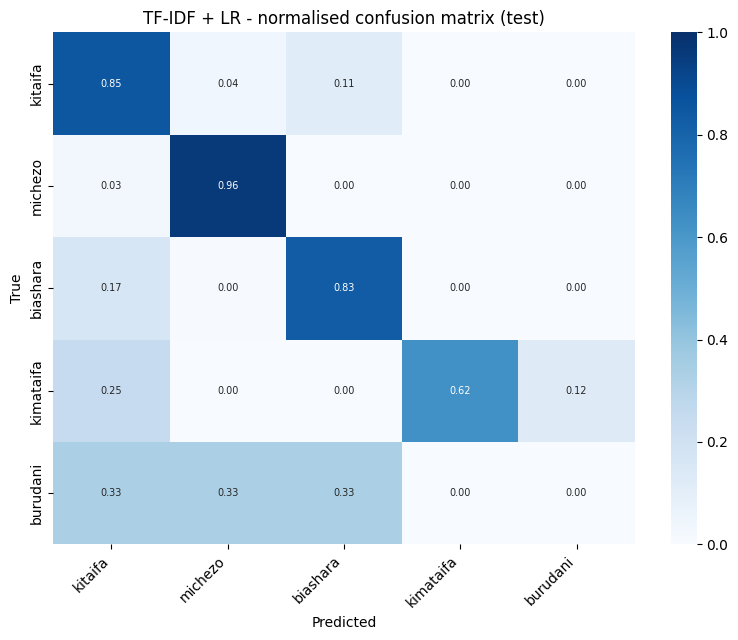

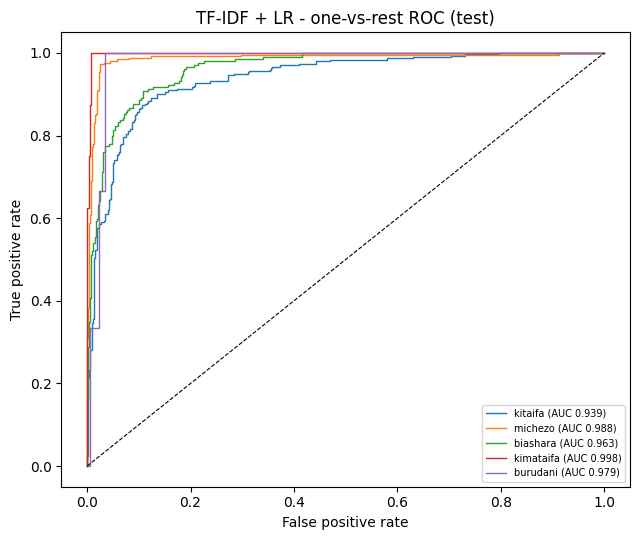

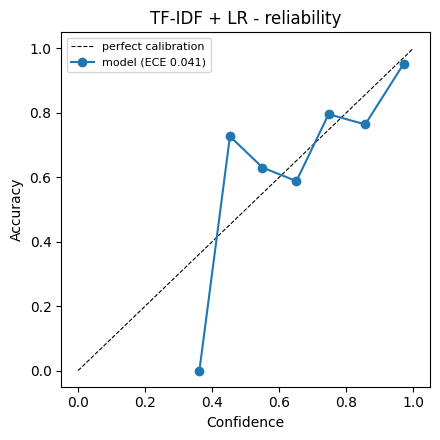

{
  "log_loss": 0.3583,
  "accuracy": 0.8758,
  "macro_f1": 0.68,
  "weighted_f1": 0.8744,
  "top2_accuracy": 0.9871,
  "ece": 0.0414,
  "roc_auc_ovr_macro": 0.9734,
  "log_loss_ci95": [
    0.30191158296043175,
    0.41786305888866715
  ],
  "accuracy_ci95": [
    0.8525226390685641,
    0.8991267787839585
  ],
  "macro_f1_ci95": [
    0.6048871178825797,
    0.725553429687633
  ],
  "model": "TF-IDF + LR",
  "key": "baseline_tfidf_lr",
  "selected_experiment": "BL-03",
  "C": 16.0
}
Submission written to /content/swahili-news-sequential/submissions/baseline_tfidf_lr.csv


PosixPath('/content/swahili-news-sequential/submissions/baseline_tfidf_lr.csv')

In [12]:
best_id = min(results_lr, key=lambda k: results_lr[k][2]["log_loss"])
e, Cval, _ = results_lr[best_id]
Xtr, Xte, Xz = tfidf_features(e["cfg"], tr.content, te.content, zindi.content)
clf = LogisticRegression(C=Cval, max_iter=3000, class_weight="balanced" if e["cfg"].get("balanced") else None).fit(Xtr, ytr)
save_final_results("baseline_tfidf_lr", "TF-IDF + LR", yte, clf.predict_proba(Xte), C.CLASSES, te.id.values,
                   extra={"selected_experiment": best_id, "C": Cval})
make_submission(zindi, clf.predict_proba(Xz), C.CLASSES, "baseline_tfidf_lr")

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.13/dist

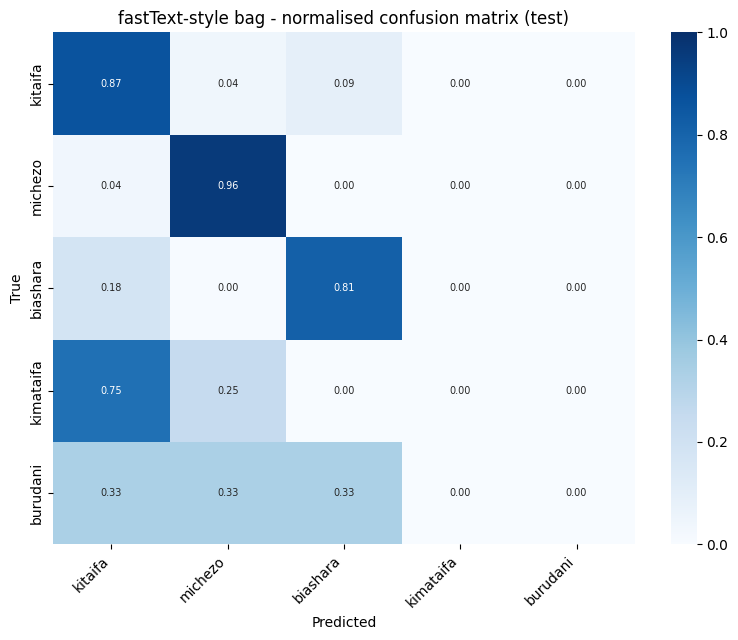

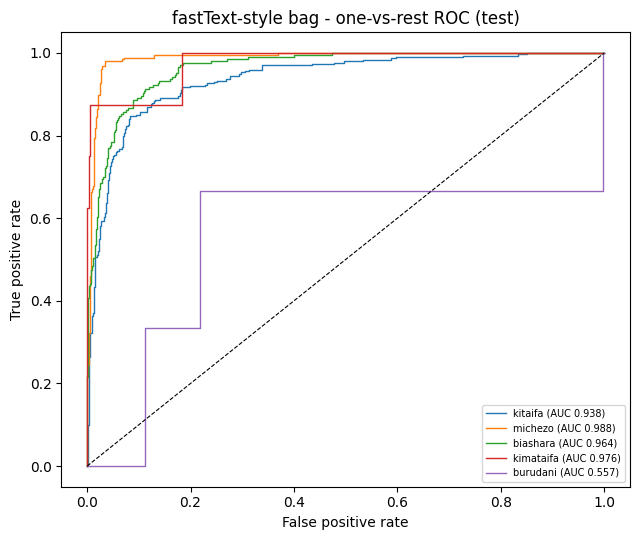

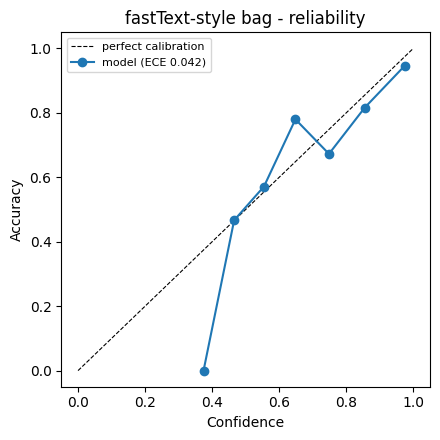

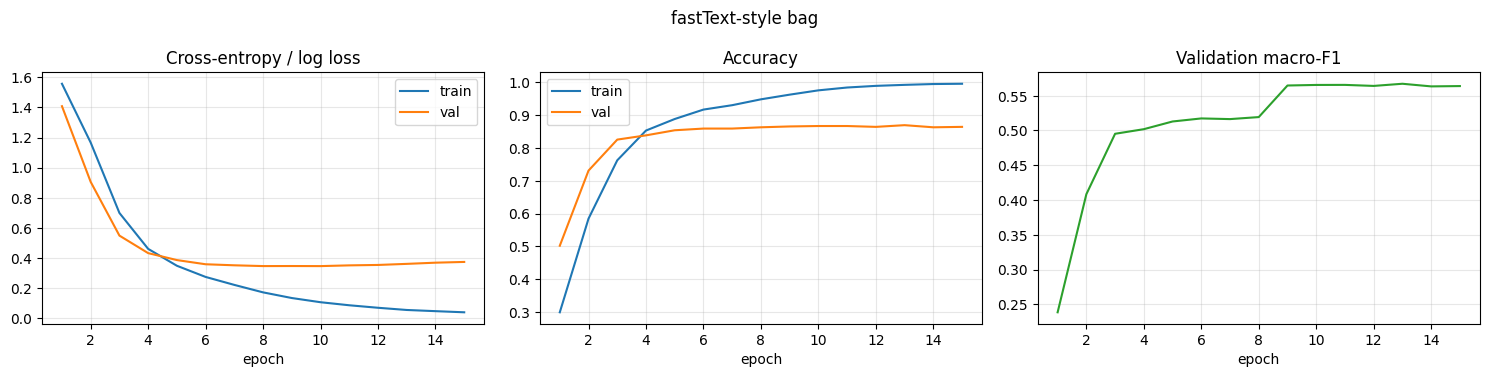

{
  "log_loss": 0.382,
  "accuracy": 0.8706,
  "macro_f1": 0.525,
  "weighted_f1": 0.8642,
  "top2_accuracy": 0.9845,
  "ece": 0.0421,
  "roc_auc_ovr_macro": 0.8846,
  "log_loss_ci95": [
    0.32039730341624206,
    0.4469274352113947
  ],
  "accuracy_ci95": [
    0.8460543337645536,
    0.8926584734799482
  ],
  "macro_f1_ci95": [
    0.5108199893659897,
    0.5384428566940941
  ],
  "model": "fastText-style bag",
  "key": "baseline_fasttext",
  "selected_experiment": "FT-01",
  "n_trainable_params": 2685905,
  "val_log_loss": 0.3443
}
Submission written to /content/swahili-news-sequential/submissions/baseline_fasttext.csv


In [13]:
_ = finalize(best_ft, build_model, TokenDataset(seq["te"], yte), yte, te.id.values, C.CLASSES,
         key="baseline_fasttext", display_name="fastText-style bag", collate_fn=pad_collate,
         zindi_ds=TokenDataset(seq["z"]), zindi_df=zindi, save_weights=False)

> **Write-up notes:** compare BL-01→BL-02 (morphology), BL-02→BL-03 (imbalance: check minority-class
> recall in `results/baseline_tfidf_lr/per_class.csv`, not just the averages), BL-04 vs BL-05 (where
> the signal is), BL-06 (stop-words). Fill the `observation` column in `experiments/log_tf_idf_lr.csv`.

In [14]:
from src.utils import persist_outputs
persist_outputs()

Outputs copied to /content/drive/MyDrive/swahili-news/outputs


In [ ]:
!cp "/content/swahili-news-sequential/notebooks/02_baselines.ipynb" /content/swahili-news-sequential/notebooks/02_baselines.ipynb
!cd /content/swahili-news-sequential && git status